EDA Project with Python and Libraries(Numpy,Pandas,Matplotlib,Seaborn)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("Diwali_Sales_Data.csv")
data

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra�Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


Data cleaning

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [3]:
#unessecary and blank coloums deletion
data.drop(['Status','unnamed1'],axis=1,inplace=True)
data

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra�Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


In [4]:
pd.isnull(data).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [5]:
#for removing amount coloumn null value
data.dropna(inplace=True)

In [6]:
print(data.shape)
pd.isnull(data).sum()

(11239, 13)


User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [7]:
#data type changing coloumns
data['Amount'] = data['Amount'].astype('int')

In [8]:
data[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


Exploratory Data Analysis

In [9]:
data.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

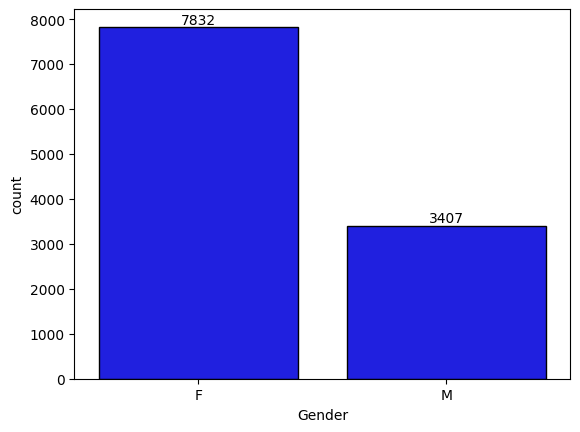

In [10]:
ax = sns.countplot(x='Gender',data = data,color='blue',edgecolor='black')
#labeling bars
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

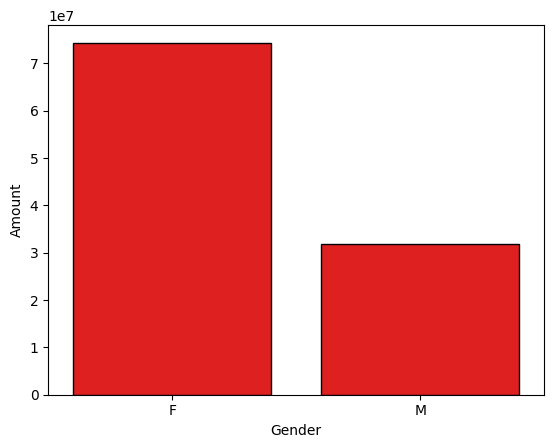

In [11]:
sales_gender = data.groupby(['Gender'] , as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(x='Gender',y='Amount',data = sales_gender,color='red',edgecolor='black')

From the above Graphs we can conclude that Females are the most buyers , purchasing power of females are greater than Males!

Age

<Axes: xlabel='Age Group', ylabel='count'>

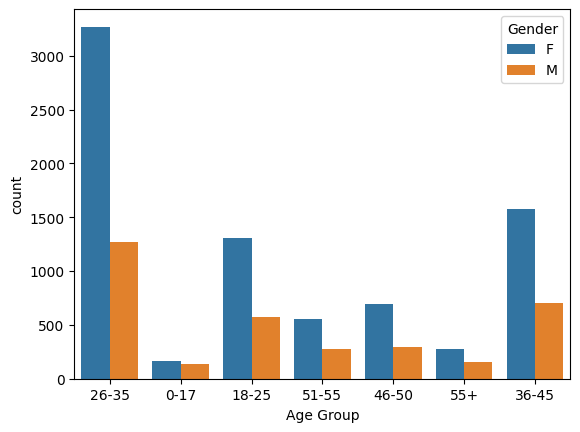

In [12]:
#count of age groups who are more frequent in shopping with Gender based division
sns.countplot(data=data, x = 'Age Group', hue='Gender')

Most of the buyers are of age group between 26-35yrs Females

State

<Axes: xlabel='State', ylabel='Orders'>

d:\code\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  func(*args, **kwargs)
d:\code\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


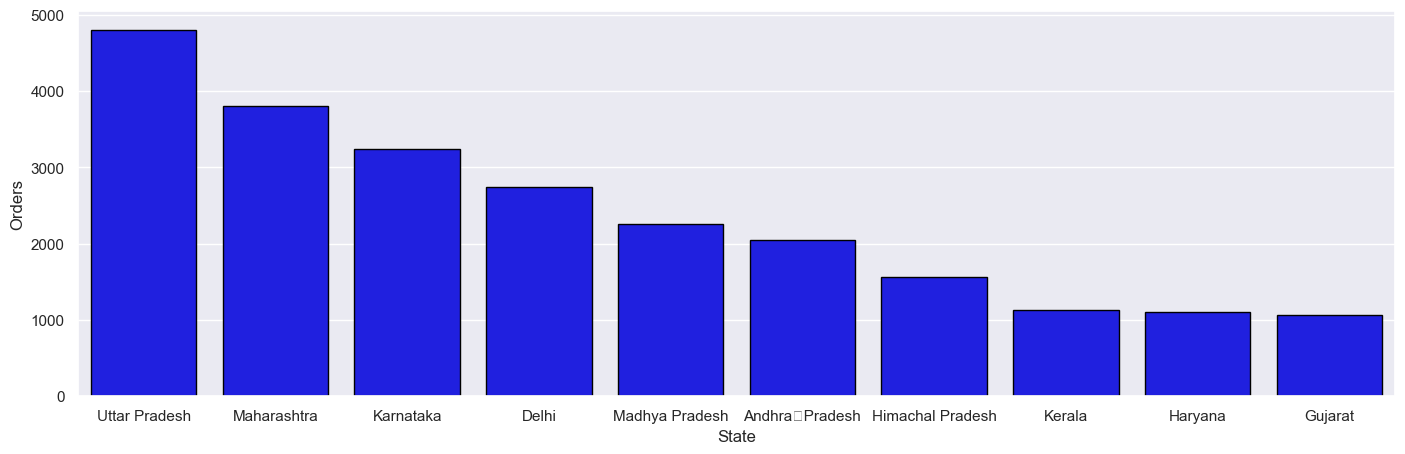

In [13]:
#to analyse total number of orders state wise (10 states)
sales_state = data.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)
sns.set(rc={'figure.figsize':(17,5)})
sns.barplot(data = sales_state, x='State',y='Orders',color='blue',edgecolor='black')

<Axes: xlabel='State', ylabel='Amount'>

d:\code\venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  func(*args, **kwargs)
d:\code\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


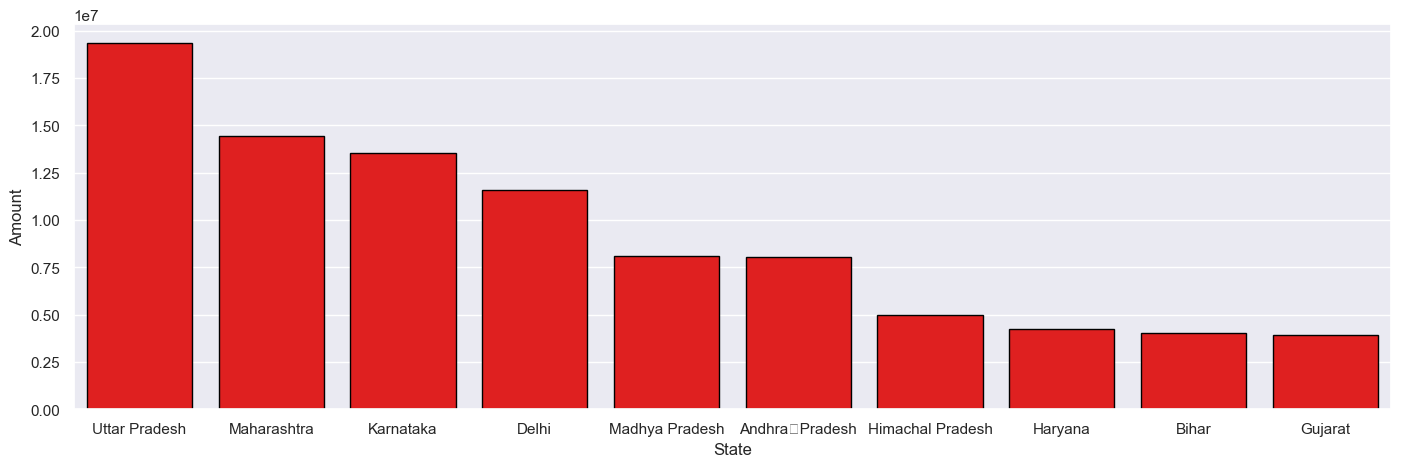

In [14]:
#amount of sales in diffrent states
sales_amount = data.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set({'figure.figsize':(17,5)})
sns.barplot(data = sales_amount,x='State',y='Amount',color='red',edgecolor='black')

By analysing the above graph we can conclude that most amount of sales are from Uttarpredesh , then Maharashtra , Karnatka as so on...

Maritial Status

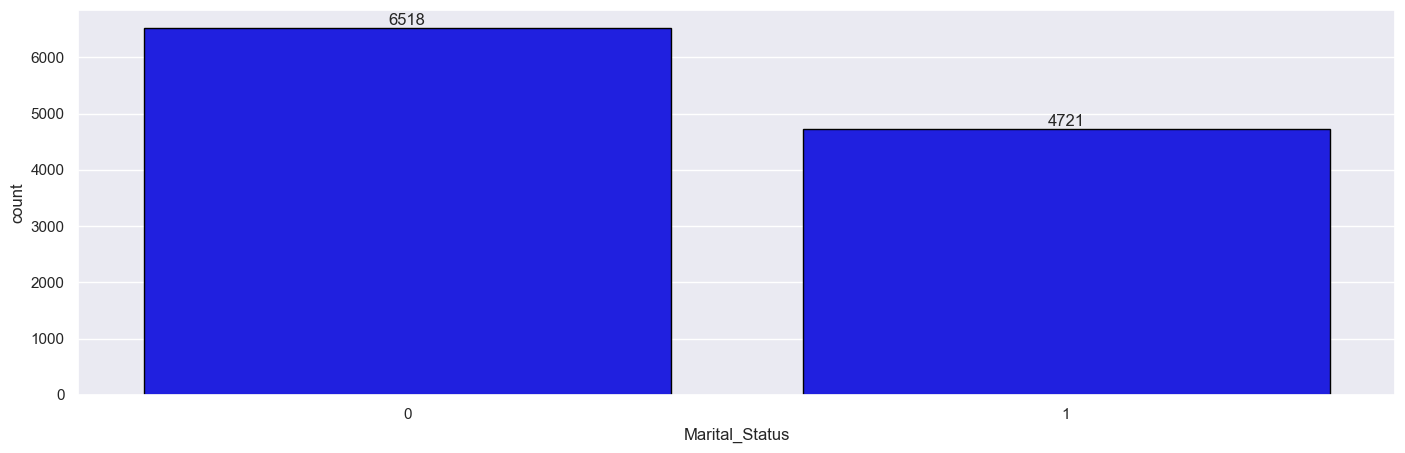

In [15]:
ax = sns.countplot(data=data , x = 'Marital_Status',color='blue',edgecolor='black')
sns.set({'figure.figsize':(7,5)})
for bars in ax.containers:
    ax.bar_label(bars)


From the above graph, we can conclude that married people usually have high purchasing power

<Axes: xlabel='Marital_Status', ylabel='Amount'>

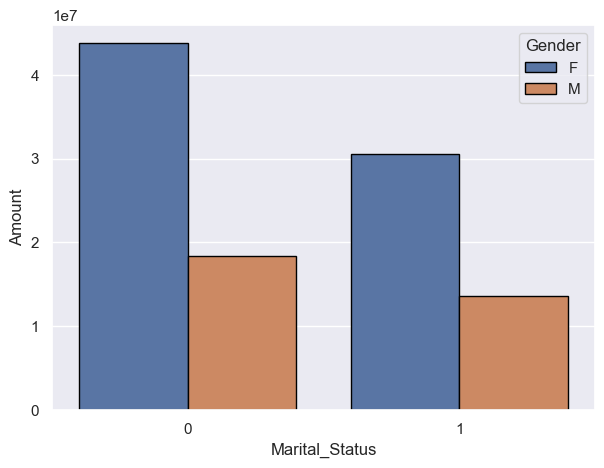

In [16]:
sales_gdr = data.groupby(['Marital_Status','Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(data = sales_gdr,x='Marital_Status',y='Amount',hue='Gender',edgecolor='black')

From the above graph, we can conclude that married women have high purchasing power. 

Occuapation

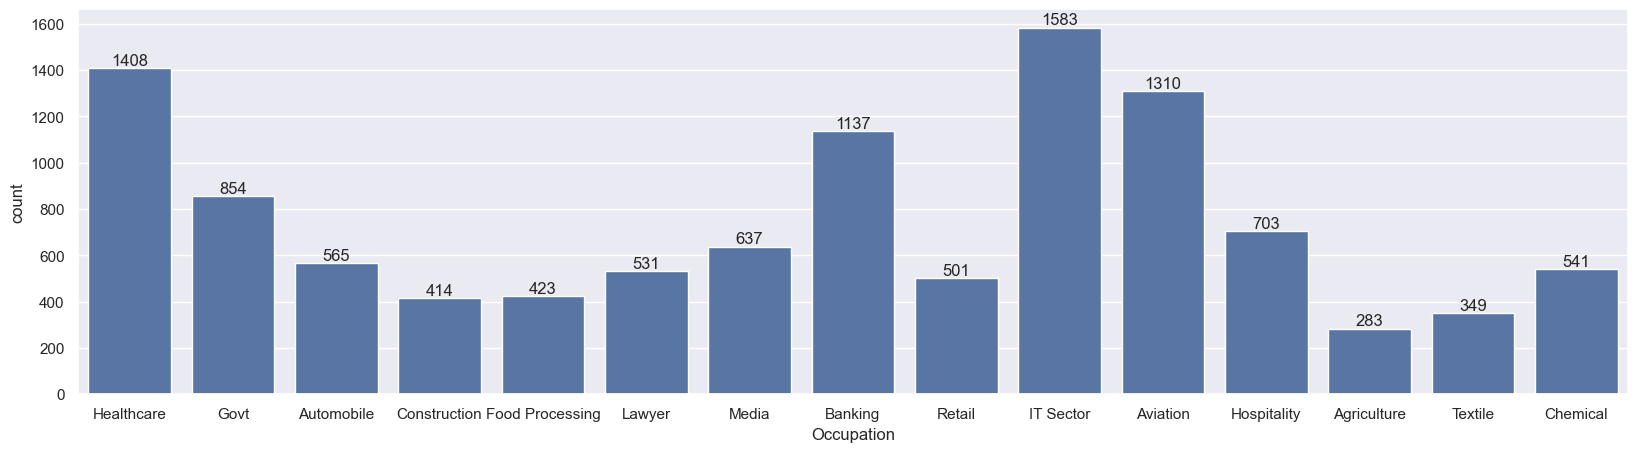

In [17]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = data, x = "Occupation")

for bars in ax.containers:
    ax.bar_label(bars)

Text(0.5, 1.0, "Occupation's purchasing powers")

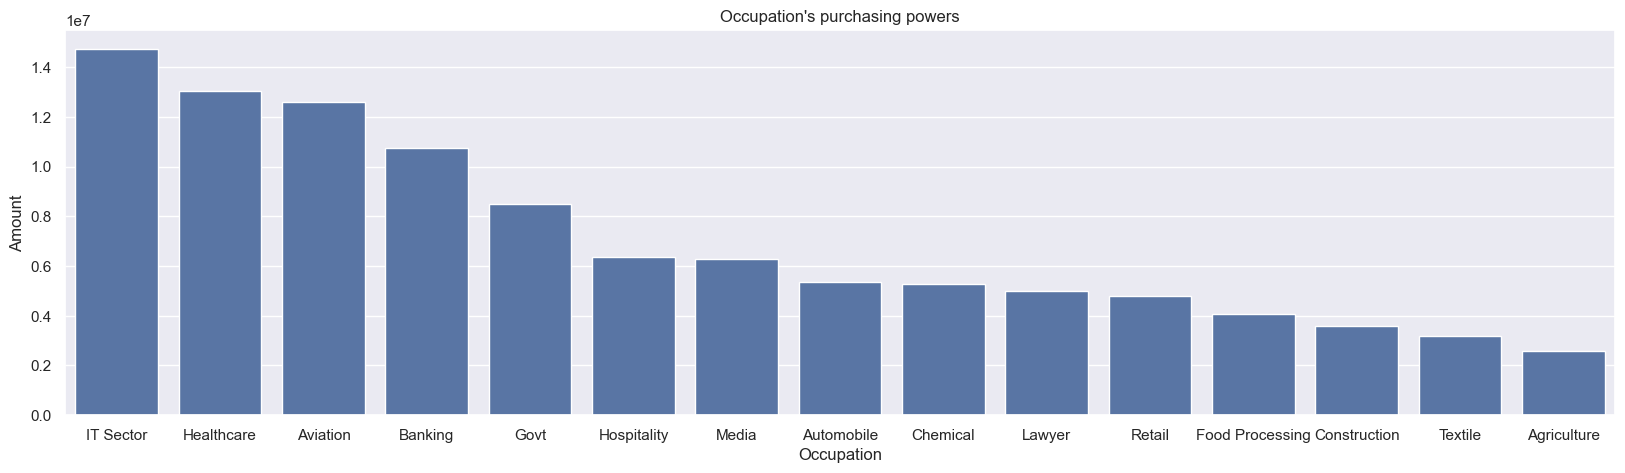

In [18]:
sales_states = data.groupby(['Occupation'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.set(rc={'figure.figsize':(20,5)})
plt=sns.barplot(data = sales_states,x='Occupation',y='Amount')
plt.set_title("Occupation's purchasing powers")

From the above graph we can see that most of the buyers are working in IT,Healthcare and Aviation sector.

PRODUCT CATEGORY

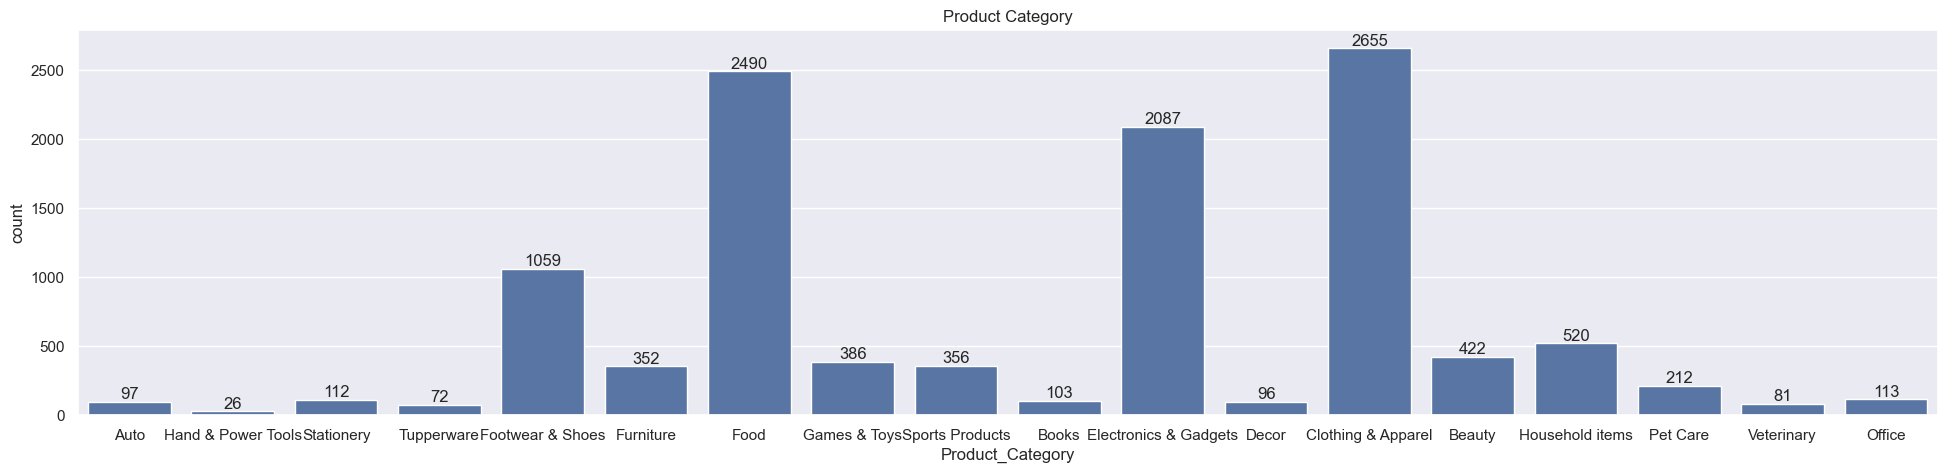

In [19]:
sns.set(rc={'figure.figsize':(24,5)})
ax = sns.countplot(data = data , x = "Product_Category")
ax.set_title("Product Category")
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

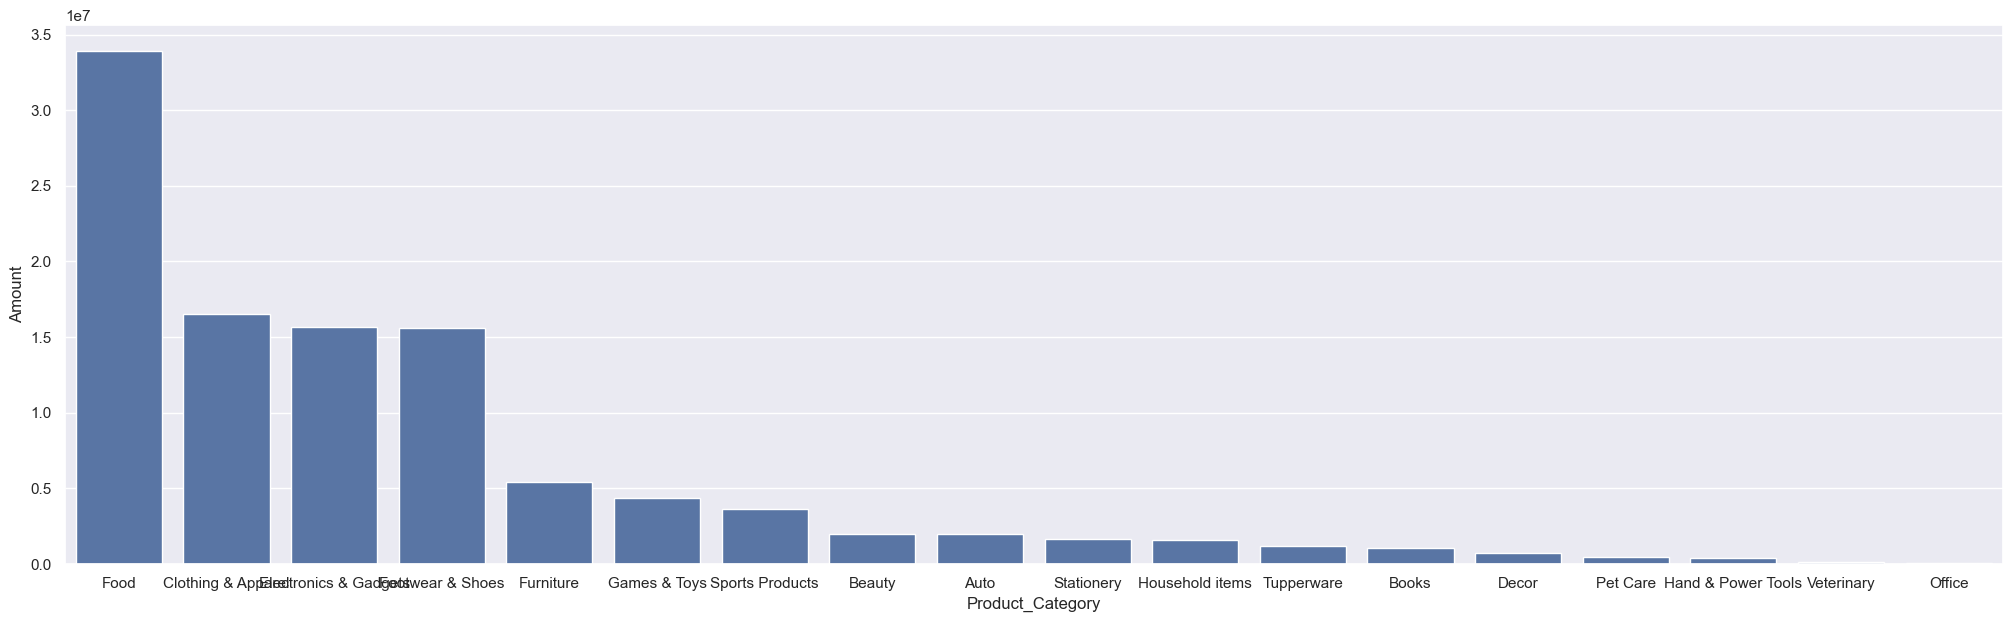

In [20]:
sales_product = data.groupby(["Product_Category"],as_index=False)['Amount'].sum().sort_values(by="Amount",ascending=False)
sns.set(rc={'figure.figsize':(25,7)})
sns.barplot(data=sales_product,x="Product_Category",y="Amount")

From the above graphs we can conclude that Food , Clothing & Appealings and gadgets are the top 3 most Amount of sales 

Text(0.5, 1.0, "Top 5 most ordered Product ID's")

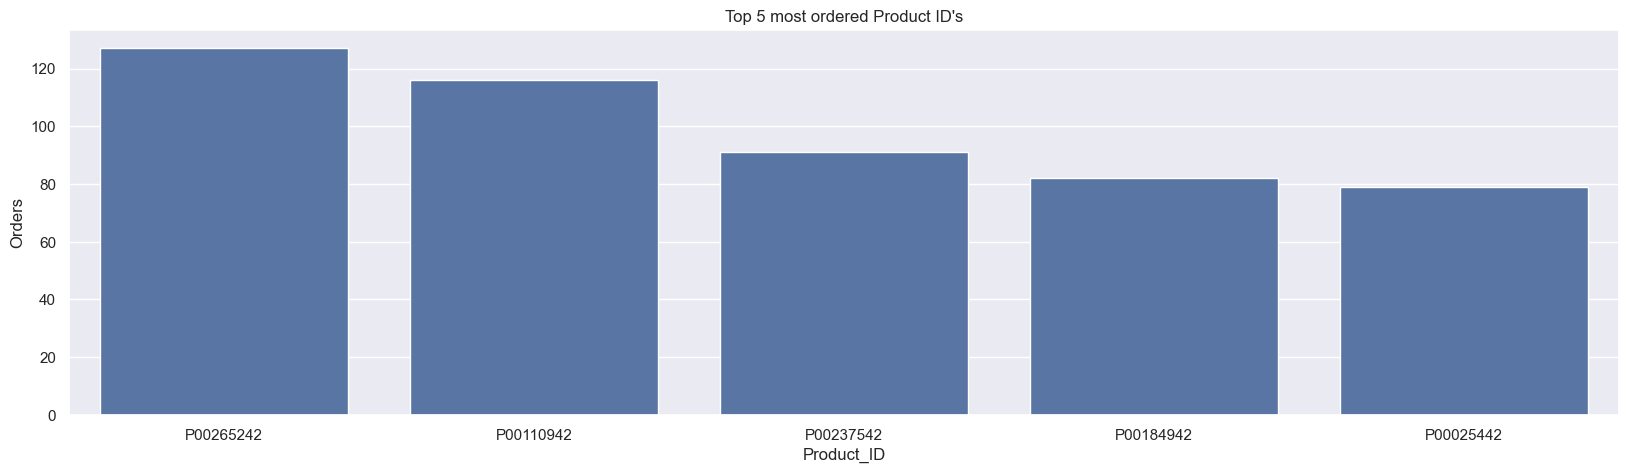

In [21]:
sales_states = data.groupby(['Product_ID'],as_index=False)['Orders'].sum().sort_values(by="Orders",ascending=False).head(5)
sns.set(rc={"figure.figsize":(20,5)})
plt1 = sns.barplot(data = sales_states,x="Product_ID",y="Orders")
plt1.set_title("Top 5 most ordered Product ID's")

CONCLUSION:

Married women age group 26-35 years from UP, Maharashtra, and Karnataka working in IT, Healthcare and Aviation are most likely buy products from Food , Clothing and Electronics categories. 